# Module 07 — Data Preprocessing & Feature Engineering
## Titanic Dataset (Missing Values) + Heart Dataset (Encoding + Scaling)
---
> **Preprocessing** মানে raw data-কে ML model-এর জন্য তৈরি করা।  
> Model কখনো messy, unclean data বুঝতে পারে না।  
> এই module-এ শিখব: Missing values, Encoding, এবং Scaling — তিনটি core preprocessing step।

| Section | Topic | Dataset |
|---|---|---|
| 7.1 | Preprocessing কেন দরকার | General |
| 7.2 | Example Dataset দিয়ে বোঝা | Custom |
| 7.3-7.4 | Missing Values handle করা | Titanic |
| 7.5 | Categorical Encoding | Heart |
| 7.6-7.7 | Normalization ও Scaling | Heart |
| 7.8 | Conclusion ও Best Practices | — |


---
## 7.1 Data Preprocessing কেন দরকার?

### Real Data সবসময় Messy!

```
Real World Data Problems:
  Missing values    -> Age = NaN, Cabin = NaN
  Wrong format      -> '25' (string) instead of 25 (int)
  Categorical text  -> 'male'/'female' -> model বোঝে না!
  Different scales  -> Age: 0-80, Salary: 20,000-700,000
  Outliers          -> Age = 999 (data entry error)
```

### ML Model কী চায়?
```
ML Model চায়:             Raw Data-তে আছে:
  Numbers (float/int)  <->  'male', 'female', 'S', 'C'
  No missing values    <->  Age: 177 NaN, Cabin: 687 NaN
  Same scale           <->  Age: 0-80 vs Salary: 20k-700k
  No outliers          <->  Fare: 0.0 to 512.3
```

### Preprocessing Pipeline
```
Raw Data
   |
   v
1. Handle Missing Values  -> NaN fill বা drop
   |
   v
2. Encode Categorical      -> Label / OneHot Encoding
   |
   v
3. Scale / Normalize       -> StandardScaler / MinMaxScaler
   |
   v
Clean Data -> Model Training
```

### 🎯 Interview Topics
- Preprocessing কেন করতে হয়? → Model numeric data চায়, missing থাকলে error, scale আলাদা হলে bias
- কোন step আগে করতে হয়? → Missing values আগে, তারপর encoding, তারপর scaling
- Scaling কি সবসময় দরকার? → Tree-based models (Random Forest, XGBoost)-এ দরকার নেই, কিন্তু Linear/KNN/SVM-এ অবশ্যই দরকার
- Fit শুধু train-এ কেন? → Test data-র information train-এ গেলে data leakage হয়


---
## 7.2 Preprocessing কেন দরকার — Example Dataset

### PPTX Slide-এর Example

একটি ছোট dataset দিয়ে বোঝা যাক কেন preprocessing না করলে কী সমস্যা হয়:

```
Name    Age    Salary    City      Purchased
Alice   25     50000     Dhaka     Yes
Bob     ?      80000     Chittagong No
Carol   30     ?         Dhaka     Yes
David   35     60000     Khulna    No
```

**সমস্যা:**
- Bob-এর Age missing → model কী করবে?
- Carol-এর Salary missing → average নেবো?
- City = 'Dhaka', 'Chittagong', 'Khulna' → model এগুলো বোঝে না
- Purchased = 'Yes'/'No' → 1/0 করতে হবে
- Age (25-35) vs Salary (50k-80k) → scale একেবারে আলাদা

### 🎯 Interview Topics
- Missing value imputation strategy কীভাবে বেছে নেবে?
  - Numeric + symmetric → **mean**
  - Numeric + skewed → **median** (outlier-robust)
  - Categorical → **mode** (most frequent)
  - Missing > 50% → **drop** the column


In [56]:
# Now we create the small example dataset from the PPTX slide

import numpy as np
import pandas as pd

# Here we simulate the example dataset with missing values and mixed types
data = {
    "Name": ["Alice", "Bob", "Carol", "David", "Eva", "Frank"],
    "Age": [25, np.nan, 30, 35, np.nan, 28],
    "Salary": [50000, 80000, np.nan, 60000, 75000, np.nan],
    "City": ["Dhaka", "Chittagong", "Dhaka", "Khulna", "Dhaka", "Chittagong"],
    "Purchased": ["Yes", "No", "Yes", "No", "Yes", "No"]
}

df_example = pd.DataFrame(data)
print("Raw dataset (with problems):")
print(df_example)
print()
print("Missing values:")
print(df_example.isnull().sum())
print()
print("Data types:")
print(df_example.dtypes)

Raw dataset (with problems):
    Name   Age   Salary        City Purchased
0  Alice  25.0  50000.0       Dhaka       Yes
1    Bob   NaN  80000.0  Chittagong        No
2  Carol  30.0      NaN       Dhaka       Yes
3  David  35.0  60000.0      Khulna        No
4    Eva   NaN  75000.0       Dhaka       Yes
5  Frank  28.0      NaN  Chittagong        No

Missing values:
Name         0
Age          2
Salary       2
City         0
Purchased    0
dtype: int64

Data types:
Name          object
Age          float64
Salary       float64
City          object
Purchased     object
dtype: object


> 📝 **এই code-এ কী হচ্ছে:** PPTX slide-এর example dataset তৈরি করা হয়েছে। Bob-এর Age এবং Carol-Frank-এর Salary missing। City ও Purchased column string — model এগুলো সরাসরি বুঝতে পারে না। `isnull().sum()` দিয়ে প্রতিটি column-এ কতটি NaN আছে দেখা হয়েছে।

In [57]:
# Now we fix the example dataset step by step

# Step 1: Fill missing numeric values
df_fixed = df_example.copy()

# Here we fill Age with median (robust to outliers)
df_fixed["Age"] = df_fixed["Age"].fillna(df_fixed["Age"].median())

# Here we fill Salary with mean
df_fixed["Salary"] = df_fixed["Salary"].fillna(df_fixed["Salary"].mean())

# Step 2: Encode categorical columns
# Purchased: Yes=1, No=0 (binary -> simple map)
df_fixed["Purchased"] = df_fixed["Purchased"].map({"Yes": 1, "No": 0})

# City: OneHot encoding (no ordinal relationship)
df_fixed = pd.get_dummies(df_fixed, columns=["City"], dtype=int)

# Step 3: Drop non-numeric Name column
df_fixed = df_fixed.drop(columns=["Name"])

print("Cleaned and encoded dataset:")
print(df_fixed)
print()
print("No missing values:", df_fixed.isnull().sum().sum() == 0)

Cleaned and encoded dataset:
    Age   Salary  Purchased  City_Chittagong  City_Dhaka  City_Khulna
0  25.0  50000.0          1                0           1            0
1  29.0  80000.0          0                1           0            0
2  30.0  66250.0          1                0           1            0
3  35.0  60000.0          0                0           0            1
4  29.0  75000.0          1                0           1            0
5  28.0  66250.0          0                1           0            0

No missing values: True


> 📝 **এই code-এ কী হচ্ছে:** Example dataset-কে step by step clean করা হয়েছে। Age median দিয়ে, Salary mean দিয়ে fill করা হয়েছে। Purchased binary হওয়ায় simple map দিয়ে 1/0 করা হয়েছে। City-তে কোনো order নেই তাই OneHot encoding ব্যবহার করা হয়েছে।

---
## 7.3–7.4 Missing Values — Titanic Dataset

### Real-life Analogy (Module Notebook থেকে)
> Attendance sheet-এর blank cells-এর মতো।  
> কিছু student 'P' (present), কিছু 'A' (absent), কিছু blank।  
> এই blank-গুলো ignore করলে calculation ভুল হবে।

### Titanic Dataset-এ সমস্যা কোথায়?

| Column | Missing | কী করব |
|---|---|---|
| Age | ~177 NaN | **Median দিয়ে fill** (right-skewed distribution) |
| Embarked | 2 NaN | **Mode দিয়ে fill** (categorical, most frequent = 'S') |
| Cabin | ~687 NaN | **Drop** (75%+ missing, too many unique values) |

### Missing Value Strategy কীভাবে বেছে নেব?
```
Numeric column:
  Distribution symmetric? -> mean
  Distribution skewed?    -> median  (outlier-robust)
  Domain knowledge আছে?  -> domain-specific value

Categorical column:
  -> mode (সবচেয়ে বেশিবার আসা value)

Column-ই drop করব কখন?
  Missing > 50-60% হলে
  Column-টি কম important হলে
```

### 🎯 Interview Topics
- `fillna(median)` কেন mean নয়? → Age right-skewed, বড় outlier (80-year-old) mean টানে উপরে, median stable থাকে
- `mode()[0]` কেন `[0]`? → `mode()` Series return করে, `[0]` দিয়ে first (most frequent) value নেওয়া হয়
- KNN Imputation কী? → Similar rows দেখে missing value fill করে, mean/median-এর চেয়ে smart
- Forward fill কখন? → Time series data-তে আগের observation দিয়ে fill করা
- `inplace=True` vs re-assignment → দুটোই কাজ করে, re-assignment safer


In [58]:
# Now we load the Titanic dataset
# Exact code from the module notebook

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Titanic -- use your local path or read from seaborn
# Option 1 (local): df_titanic = pd.read_csv("Titanic-Dataset.csv")
df_titanic = pd.read_csv("Titanic-Dataset.csv")

# Option 2 (built-in seaborn -- no file needed):
# df_titanic = sns.load_dataset("titanic")

# Here we standardize column names to match module notebook
df_titanic = df_titanic.rename(columns={
    "survived":  "Survived",
    "pclass":    "Pclass",
    "sex":       "Sex",
    "age":       "Age",
    "sibsp":     "SibSp",
    "parch":     "Parch",
    "fare":      "Fare",
    "embarked":  "Embarked",
    "deck":      "Cabin"
})

print("First 10 rows:")
print(df_titanic[["Survived","Pclass","Sex","Age","SibSp","Parch","Fare","Embarked","Cabin"]].head(10))

First 10 rows:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked Cabin
0         0       3    male  22.0      1      0   7.2500        S   NaN
1         1       1  female  38.0      1      0  71.2833        C   C85
2         1       3  female  26.0      0      0   7.9250        S   NaN
3         1       1  female  35.0      1      0  53.1000        S  C123
4         0       3    male  35.0      0      0   8.0500        S   NaN
5         0       3    male   NaN      0      0   8.4583        Q   NaN
6         0       1    male  54.0      0      0  51.8625        S   E46
7         0       3    male   2.0      3      1  21.0750        S   NaN
8         1       3  female  27.0      0      2  11.1333        S   NaN
9         1       2  female  14.0      1      0  30.0708        C   NaN


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর Titanic loading code। Local file না থাকলে seaborn-এর built-in Titanic dataset ব্যবহার করা হয়েছে — একই structure। Column rename করা হয়েছে যাতে module notebook-এর সাথে match করে।

In [59]:
# Now we check shape and unique values (module notebook cell 4 & 5)

print("Shape (Rows and Columns):", df_titanic[["Survived","Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]].shape)
print()
print("Unique values per column:")
# print(df_titanic[["Survived","Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]].nunique())
df_titanic[["Survived","Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]].nunique()

Shape (Rows and Columns): (891, 8)

Unique values per column:


Survived      2
Pclass        3
Sex           2
Age          88
SibSp         7
Parch         7
Fare        248
Embarked      3
dtype: int64

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর `df_titanic.shape` ও `df_titanic.nunique()` code। `shape` দেয় (rows, columns)। `nunique()` প্রতিটি column-এ unique values-এর সংখ্যা — binary feature চেনার উপায়।

In [60]:
# Now we check missing values (module notebook cell 6)

print("Missing values per column:")
print(df_titanic.isnull().sum())
print()
print("Missing percentage:")
print((df_titanic.isnull().mean() * 100).round(2))

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing percentage:
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর missing values check। `isnull().sum()` প্রতিটি column-এ NaN count দেয়। `.mean() * 100` percentage হিসাবে দেখায় — Cabin 75%+ missing, Age ~20% missing।

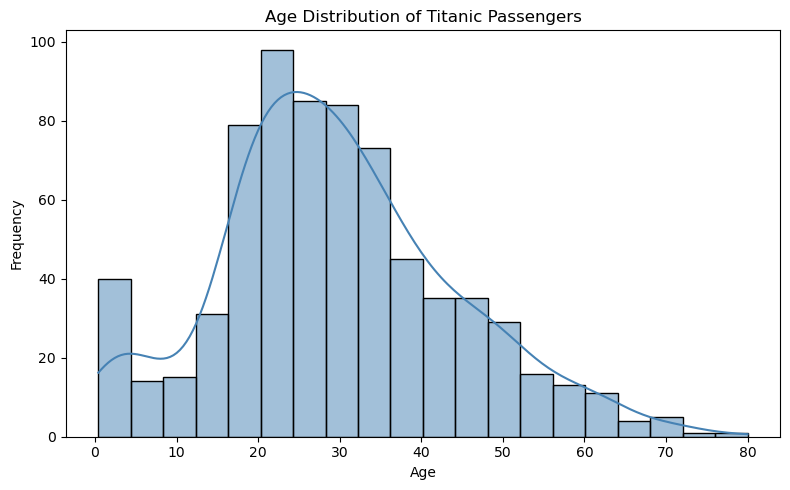

Age Mean:   29.70
Age Median: 28.00

Distribution is right-skewed -> Median is more robust than Mean!
(A few old passengers pull the mean up, median stays stable)


In [61]:
# Now we visualize Age distribution to choose fill strategy
# (module notebook cell 7 -- why median not mean?)

plt.figure(figsize=(8, 5))
sns.histplot(df_titanic["Age"].dropna(), kde=True, bins=20, color="steelblue")
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Here we calculate mean and median to show the difference
age_mean   = df_titanic["Age"].mean()
age_median = df_titanic["Age"].median()

print(f"Age Mean:   {age_mean:.2f}")
print(f"Age Median: {age_median:.2f}")
print()
print("Distribution is right-skewed -> Median is more robust than Mean!")
print("(A few old passengers pull the mean up, median stays stable)")

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর Age distribution plot। Right-skewed distribution-এ কিছু বয়স্ক passenger mean-কে উপরে টানে। Median সেই outlier-এ প্রভাবিত হয় না — তাই Age fill-এ median ব্যবহার করা হবে। এই visualization-ই দেখিয়ে দেয় কোন imputation strategy বেছে নিতে হবে।

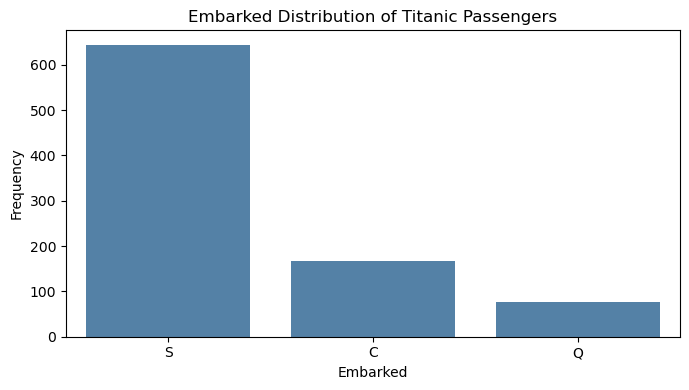

Embarked value counts:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Mode of Embarked: S
Most passengers embarked from 'S' (Southampton) -> fill NaN with 'S'


In [62]:
# Now we visualize Embarked to choose fill strategy
# (module notebook cell 8)

plt.figure(figsize=(7, 4))
sns.countplot(data=df_titanic, x="Embarked", color="steelblue")
plt.title("Embarked Distribution of Titanic Passengers")
plt.xlabel("Embarked")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Embarked value counts:")
print(df_titanic["Embarked"].value_counts())
print()
print("Mode of Embarked:", df_titanic["Embarked"].mode()[0])
print("Most passengers embarked from 'S' (Southampton) -> fill NaN with 'S'")

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর Embarked countplot। 'S' (Southampton) সবচেয়ে বেশি passenger — mode দিয়ে fill করার justification এখানেই। `mode()[0]` Series থেকে first (most frequent) value নেয়।

In [63]:
# Now we handle all missing values (module notebook cell 9 -- exact code)

# 1. Handle numeric missing values: Age -> fill with median
age_median = df_titanic["Age"].median()
df_titanic["Age"] = df_titanic["Age"].fillna(age_median)

# 2. Handle categorical missing values: Embarked -> fill with mode
embarked_mode = df_titanic["Embarked"].mode()[0]
df_titanic["Embarked"] = df_titanic["Embarked"].fillna(embarked_mode)

# 3. Drop Cabin -- too many missing values (75%+)
df_titanic = df_titanic.drop(columns=["Cabin"], errors="ignore")
df_titanic = df_titanic.drop(columns=["deck"],  errors="ignore")

# Here we verify no missing values remain in key columns
print("Missing values after handling:")
key_cols = ["Survived","Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]
print(df_titanic[key_cols].isnull().sum())

Missing values after handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact missing value handling code — তিনটি ভিন্ন strategy। Age → median দিয়ে fill (skewed distribution বলে)। Embarked → mode দিয়ে fill (categorical, most frequent = 'S')। Cabin → drop (75%+ missing, imputation reliable নয়)। শেষে verify করা হয়েছে কোনো missing নেই।

In [64]:
# Now we verify the result (module notebook cell 10)

print("Missing values after handling:")
key_cols = ["Survived","Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]
print(df_titanic[key_cols].isnull().sum())
print()
print("Dataset shape now:", df_titanic[key_cols].shape)
print()
print("Age stats after fill:")
print(df_titanic["Age"].describe().round(2))

Missing values after handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Dataset shape now: (891, 8)

Age stats after fill:
count    891.00
mean      29.36
std       13.02
min        0.42
25%       22.00
50%       28.00
75%       35.00
max       80.00
Name: Age, dtype: float64


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর verification step। সব key column-এ 0 missing values — preprocessing সফল। Age-এর describe() দেখলে median-এর কাছাকাছি mean থাকে — imputation ঠিকঠাক হয়েছে।

---
### Missing Value Handling — Advanced Techniques

| Technique | কখন ব্যবহার | sklearn class |
|---|---|---|
| Mean imputation | Numeric + symmetric | `SimpleImputer(strategy='mean')` |
| Median imputation | Numeric + skewed | `SimpleImputer(strategy='median')` |
| Mode imputation | Categorical | `SimpleImputer(strategy='most_frequent')` |
| Constant fill | Domain-specific default | `SimpleImputer(strategy='constant', fill_value=0)` |
| KNN imputation | Similar rows দেখে fill | `KNNImputer(n_neighbors=5)` |
| Drop column | Missing > 50-60% | `df.drop(columns=[...])` |
| Drop row | Very few missing rows | `df.dropna()` |

### 🎯 KNN Imputer কেন ভালো?
> Mean/Median সব passenger-এর average নেয়।  
> KNN Imputer similar age, class, fare-এর passenger দেখে fill করে — আরো realistic।


In [65]:
# Now we show sklearn's SimpleImputer and KNNImputer

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer, KNNImputer

# Now we create a small dataset with missing values
sample = pd.DataFrame({
    "Age": [22.0, np.nan, 38.0, 35.0, np.nan, 27.0, np.nan, 54.0],
    "Fare": [7.25, 71.28, np.nan, 53.1, 8.05, np.nan, 21.0, 51.86],
    "Pclass": [3, 1, 3, 1, 3, 3, 3, 2]
})

print("Original data with missing values:")
print(sample)

# Method 1: SimpleImputer with median
si = SimpleImputer(strategy="median")
filled_median = pd.DataFrame(si.fit_transform(sample), columns=sample.columns)

# Method 2: KNN Imputer
knn_imp = KNNImputer(n_neighbors=3)
filled_knn = pd.DataFrame(knn_imp.fit_transform(sample), columns=sample.columns)

print()
print("After Median Imputation:")
print(filled_median.round(2))

print()
print("After KNN Imputation (k=3):")
print(filled_knn.round(2))

print()
print("KNN fills based on 3 similar neighbouring rows, so values are more realistic!")

Original data with missing values:
    Age   Fare  Pclass
0  22.0   7.25       3
1   NaN  71.28       1
2  38.0    NaN       3
3  35.0  53.10       1
4   NaN   8.05       3
5  27.0    NaN       3
6   NaN  21.00       3
7  54.0  51.86       2

After Median Imputation:
    Age   Fare  Pclass
0  22.0   7.25     3.0
1  35.0  71.28     1.0
2  38.0  36.43     3.0
3  35.0  53.10     1.0
4  35.0   8.05     3.0
5  27.0  36.43     3.0
6  35.0  21.00     3.0
7  54.0  51.86     2.0

After KNN Imputation (k=3):
     Age   Fare  Pclass
0  22.00   7.25     3.0
1  33.33  71.28     1.0
2  38.00  33.44     3.0
3  35.00  53.10     1.0
4  29.00   8.05     3.0
5  27.00  33.44     3.0
6  29.00  21.00     3.0
7  54.00  51.86     2.0

KNN fills based on 3 similar neighbouring rows, so values are more realistic!


> 📝 **এই code-এ কী হচ্ছে:** sklearn-এর SimpleImputer ও KNNImputer দেখানো হয়েছে। SimpleImputer(strategy='median') সব missing-এ same median বসায়। KNNImputer k=3 মানে 3টি most similar row খুঁজে তাদের average দিয়ে fill করে — আরো intelligent। Pipeline-এ এই imputer-গুলো সহজে integrate করা যায়।

---
## 7.5 Encoding Categorical Variables — Heart Dataset

### Real-life Analogy (Module Notebook থেকে)
> Canteen token system-এর মতো।  
> 'Tehari', 'Chowmein', 'Biriyani' — billing machine বোঝে না।  
> Token: Tehari=1, Chowmein=2, Biriyani=3 করলে মনে হয় Biriyani > Chowmein > Tehari,  
> কিন্তু এই order আসলে নেই! → OneHot Encoding দরকার।

### দুই ধরনের Encoding

| Encoding | কখন | Example |
|---|---|---|
| **Label Encoding** | Binary বা Ordinal category | Sex: M=1, F=0 |
| **OneHot Encoding** | Nominal category (কোনো order নেই) | ChestPainType: ASY/NAP/ATA/TA |

### Label vs OneHot কীভাবে বুঝব?
```
Binary (2 unique value):
  Sex: M/F          -> Label Encoding (M=1, F=0)
  ExerciseAngina: Y/N -> Label Encoding (Y=1, N=0)

Ordinal (order আছে):
  Education: Low/Medium/High -> Label Encoding (0,1,2)
  Rating: Bad/Good/Excellent -> Label Encoding (0,1,2)

Nominal (কোনো order নেই):
  ChestPainType: ASY/NAP/ATA/TA -> OneHot (4 columns)
  RestingECG: Normal/ST/LVH -> OneHot (3 columns)
  City: Dhaka/Chittagong/Khulna -> OneHot (3 columns)
```

### Dummy Variable Trap (Interview Critical!)
> OneHot Encoding-এ n categories → n columns তৈরি হয়।  
> কিন্তু n-1 columns যথেষ্ট — শেষ column-টি automatically বোঝা যায়।  
> `drop_first=True` দিলে dummy variable trap avoid হয়।

### 🎯 Interview Topics
- Label Encoding nominal-এ কেন ভুল? → Model মনে করে বড় number = বেশি important
- `pd.get_dummies()` vs `OneHotEncoder` পার্থক্য? → get_dummies পুরো DataFrame-এ, OneHotEncoder sklearn Pipeline-এ ব্যবহার হয়
- Dummy variable trap কী? → Perfect multicollinearity — একটি column অন্যগুলো থেকে predict করা যায়
- High cardinality encoding কী? → Target encoding, Frequency encoding


In [66]:
# Now we load the Heart dataset (module notebook cell 12)
# Use heart.csv from your local folder

import pandas as pd
import matplotlib.pyplot as plt

# Load heart.csv -- place heart.csv in the same folder as this notebook
df_heart = pd.read_csv("Heart-Dataset.csv")

print("First 10 rows of Heart dataset:")
print(df_heart.head(10))
print()
print("Column data types:")
print(df_heart.dtypes)

First 10 rows of Heart dataset:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact Heart dataset loading code। `heart.csv` এই notebook-এর same folder-এ রাখতে হবে। `df.dtypes` দিয়ে দেখা হচ্ছে কোন columns object (string) type — এগুলোকেই encode করতে হবে।

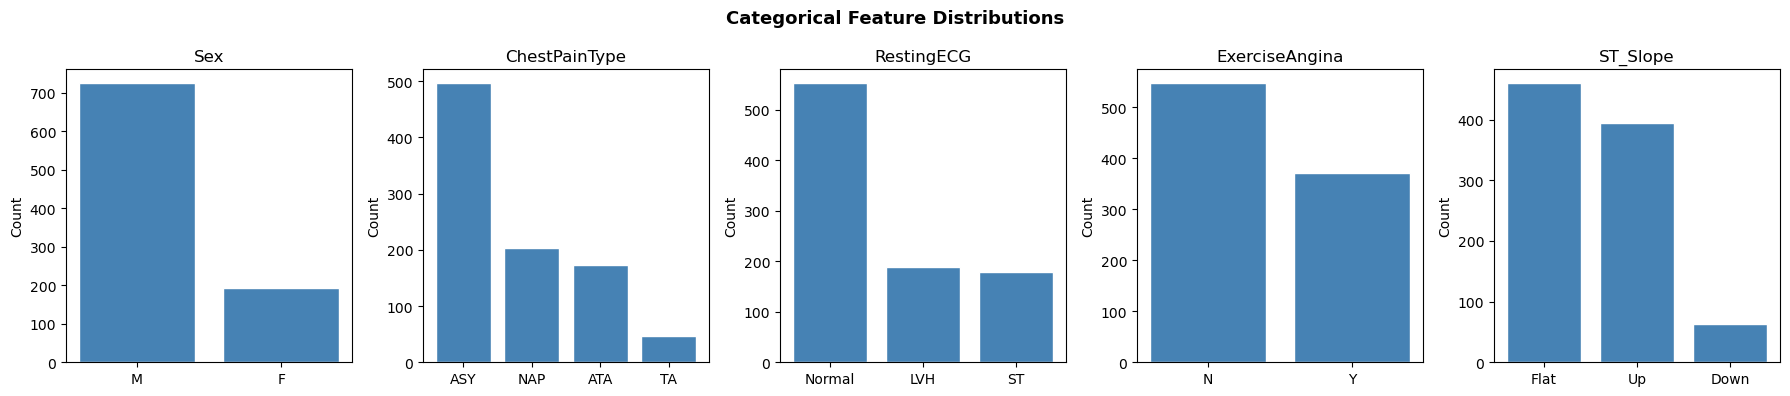

Unique values:
  Sex: ['M', 'F']
  ChestPainType: ['ATA', 'NAP', 'ASY', 'TA']
  RestingECG: ['Normal', 'ST', 'LVH']
  ExerciseAngina: ['N', 'Y']
  ST_Slope: ['Up', 'Flat', 'Down']


In [67]:
# Now we explore categorical columns (module notebook cell 13)

categorical_cols = ["Sex", "ChestPainType", "RestingECG",
                    "ExerciseAngina", "ST_Slope"]

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(18, 4))

for i, c in enumerate(categorical_cols):
    counts = df_heart[c].value_counts()
    axes[i].bar(counts.index, counts.values, color="steelblue", edgecolor="white")
    axes[i].set_title(f"{c}")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=0)

plt.suptitle("Categorical Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Here we print unique values for each categorical column
print("Unique values:")
for c in categorical_cols:
    print(f"  {c}: {df_heart[c].unique().tolist()}")

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর categorical exploration code। প্রতিটি categorical column-এর value distribution bar chart-এ দেখানো হয়েছে। Sex ও ExerciseAngina binary → Label Encoding উপযুক্ত। ChestPainType, RestingECG, ST_Slope nominal → OneHot Encoding উপযুক্ত।

In [68]:
# Now we apply Label Encoding for binary columns (module notebook cell 14)
# Binary: Sex (M/F) and ExerciseAngina (Y/N)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Here we encode Sex: F=0, M=1
df_heart["Sex"] = le.fit_transform(df_heart["Sex"])
print("Sex classes:", le.classes_)  # shows what got which number

# Here we encode ExerciseAngina: N=0, Y=1
le2 = LabelEncoder()
df_heart["ExerciseAngina"] = le2.fit_transform(df_heart["ExerciseAngina"])
print("ExerciseAngina classes:", le2.classes_)

print()
print("After Label Encoding:")
print(df_heart[["Sex", "ExerciseAngina"]].head(10))

Sex classes: ['F' 'M']
ExerciseAngina classes: ['N' 'Y']

After Label Encoding:
   Sex  ExerciseAngina
0    1               0
1    0               0
2    1               0
3    0               1
4    1               0
5    1               0
6    0               0
7    1               0
8    1               1
9    0               0


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর Label Encoding code — binary columns-এ। LabelEncoder alphabetically sort করে number assign করে: F=0, M=1 এবং N=0, Y=1। `le.classes_` দিয়ে দেখা যায় কোন label কত number পেয়েছে — এটা জানা important। Binary column-এ এটা safe কারণ শুধু দুটো value আছে।

In [69]:
# Now we verify after Label Encoding (module notebook cell 15)

print("First 10 rows after Label Encoding:")
print(df_heart.head(10))
print()
print("Unique values check:")
print("  Sex unique values:          ", df_heart["Sex"].unique())
print("  ExerciseAngina unique values:", df_heart["ExerciseAngina"].unique())

First 10 rows after Label Encoding:
   Age  Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0   40    1           ATA        140          289          0     Normal   
1   49    0           NAP        160          180          0     Normal   
2   37    1           ATA        130          283          0         ST   
3   48    0           ASY        138          214          0     Normal   
4   54    1           NAP        150          195          0     Normal   
5   39    1           NAP        120          339          0     Normal   
6   45    0           ATA        130          237          0     Normal   
7   54    1           ATA        110          208          0     Normal   
8   37    1           ASY        140          207          0     Normal   
9   48    0           ATA        120          284          0     Normal   

   MaxHR  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0    172               0      0.0       Up             0  
1    156            

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর verification step। Sex ও ExerciseAngina এখন 0 ও 1 — numeric। বাকি categorical columns (ChestPainType, RestingECG, ST_Slope) এখনো string — OneHot করতে হবে।

In [70]:
# Now we apply OneHot Encoding for nominal columns (module notebook cell 16)
# Nominal: ChestPainType, RestingECG, ST_Slope (no natural order)

cat_cols = ["ChestPainType", "RestingECG", "ST_Slope"]

# pd.get_dummies() creates one column per unique value
df_heart_encoded = pd.get_dummies(
    df_heart,
    columns=cat_cols,
    dtype=int          # output as 0/1 integers, not bool
)

print("Shape before encoding:", df_heart.shape)
print("Shape after encoding: ", df_heart_encoded.shape)
print()
print("New columns added by OneHot Encoding:")
original_cols = set(df_heart.columns)
new_cols = [c for c in df_heart_encoded.columns if c not in original_cols]
print(new_cols)

Shape before encoding: (918, 12)
Shape after encoding:  (918, 19)

New columns added by OneHot Encoding:
['ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact OneHot Encoding code। `pd.get_dummies()` প্রতিটি unique category-র জন্য আলাদা column তৈরি করে — 0 বা 1। ChestPainType 4 category → 4 new columns, RestingECG 3 → 3 columns, ST_Slope 3 → 3 columns। Total columns বেড়ে গেছে — এটাই OneHot-এর tradeoff।

In [71]:
# Now we see the final encoded dataframe (module notebook cell 17)

print("First 10 rows after all encoding:")
print(df_heart_encoded.head(10))
print()
print("All column names now:")
print(df_heart_encoded.columns.tolist())

First 10 rows after all encoding:
   Age  Sex  RestingBP  Cholesterol  FastingBS  MaxHR  ExerciseAngina  \
0   40    1        140          289          0    172               0   
1   49    0        160          180          0    156               0   
2   37    1        130          283          0     98               0   
3   48    0        138          214          0    108               1   
4   54    1        150          195          0    122               0   
5   39    1        120          339          0    170               0   
6   45    0        130          237          0    170               0   
7   54    1        110          208          0    142               0   
8   37    1        140          207          0    130               1   
9   48    0        120          284          0    120               0   

   Oldpeak  HeartDisease  ChestPainType_ASY  ChestPainType_ATA  \
0      0.0             0                  0                  1   
1      1.0             1      

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর final view। সব columns এখন numeric (0 বা 1 বা float) — model-এ দেওয়ার জন্য ready। OneHot-এ তৈরি columns-এর নাম format: `ChestPainType_ASY`, `ChestPainType_NAP` ইত্যাদি।

In [72]:
# BONUS: Dummy Variable Trap demo and fix

# Now we show what dummy variable trap looks like
print("OneHot Encoding (default -- all categories kept):")
sample_df = pd.DataFrame({"City": ["Dhaka", "Chittagong", "Khulna", "Dhaka", "Khulna"]})
encoded_all = pd.get_dummies(sample_df, dtype=int)
print(encoded_all)

print()
print("With drop_first=True (avoids dummy variable trap):")
encoded_drop = pd.get_dummies(sample_df, drop_first=True, dtype=int)
print(encoded_drop)
print()
print("Explanation:")
print("  If City_Chittagong=0 and City_Khulna=0 -> automatically Dhaka!")
print("  So we don't need City_Dhaka column -- that's drop_first=True")

OneHot Encoding (default -- all categories kept):
   City_Chittagong  City_Dhaka  City_Khulna
0                0           1            0
1                1           0            0
2                0           0            1
3                0           1            0
4                0           0            1

With drop_first=True (avoids dummy variable trap):
   City_Dhaka  City_Khulna
0           1            0
1           0            0
2           0            1
3           1            0
4           0            1

Explanation:
  If City_Chittagong=0 and City_Khulna=0 -> automatically Dhaka!
  So we don't need City_Dhaka column -- that's drop_first=True


> 📝 **এই code-এ কী হচ্ছে:** Dummy Variable Trap দেখানো হয়েছে। 3টি city → 3 columns — কিন্তু 2টি column জানলেই 3টি বোঝা যায়। `drop_first=True` দিলে প্রথম column drop হয়, multicollinearity এড়ানো যায়। Linear model-এ এই trap problem সৃষ্টি করে, tree-based model-এ কম সমস্যা।

---
## 7.6–7.7 Normalization ও Scaling

### Real-life Analogy (Module Notebook থেকে)
> Salary ও Height compare করার সমস্যা।  
> Height: 150–190 cm, Salary: 20,000–700,000 টাকা।  
> Distance-based model (KNN, SVM) দেখবে Salary-র পার্থক্য অনেক বড় → Salary dominate করবে।  
> Height-এর পার্থক্য তুলনায় tiny → Height ignore হয়ে যাবে।

### দুটি Common Scaling পদ্ধতি

#### 1. StandardScaler (Z-score Normalization)
$$z = \frac{x - \mu}{\sigma}$$

- প্রতিটি value থেকে mean বাদ দিয়ে std দিয়ে ভাগ
- Output: **mean = 0, std = 1** (Gaussian-like)
- Outlier থাকলে কিছুটা প্রভাবিত হয়
- **কখন:** Linear Regression, Logistic Regression, SVM, KNN, Neural Networks

#### 2. MinMaxScaler (Min-Max Normalization)
$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

- সব value 0 থেকে 1-এর মধ্যে আনা হয়
- Outlier-এ sensitive (outlier থাকলে সব values একদিকে চলে যায়)
- **কখন:** Neural Networks, Image pixel values, fixed range দরকার হলে

### কোনটা বেছে নেব?
| পরিস্থিতি | Scaler |
|---|---|
| Outlier আছে | **StandardScaler** (কিছুটা robust) |
| Neural Network | **MinMaxScaler** (0-1 range) |
| Unknown distribution | **StandardScaler** (safer default) |
| Fixed range চাই [0,1] | **MinMaxScaler** |

### Scaling-এর Golden Rule (Interview Critical!)
> **Scaler সবসময় শুধু Training data-তে `fit()` করবে।**  
> Test data-তে শুধু `transform()` করবে — `fit_transform()` নয়।  
> কারণ: Test data-র statistics training-এ গেলে **data leakage** হয়।

### 🎯 Interview Topics
- StandardScaler vs MinMaxScaler কখন কোনটা? → outlier থাকলে Standard, fixed range দরকার হলে MinMax
- Scaling কি Tree model-এ দরকার? → **না** — Decision Tree, Random Forest, XGBoost scale-invariant
- RobustScaler কী? → IQR দিয়ে scale করে — outlier-এ most robust
- Data leakage কেন হয়? → Test-এ fit করলে test-এর mean/std train-এ চলে আসে → optimistic performance


In [73]:
# Now we prepare features and split data (module notebook cell 19)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

# We continue from df_heart_encoded (after Label + OneHot encoding)
# If running fresh, reload and re-encode first

target_col = "HeartDisease"

X = df_heart_encoded.drop(columns=[target_col])
y = df_heart_encoded[target_col]

# Here we split: 75% train, 25% test (as in module notebook)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print()
print("Train/Test split done (75% train, 25% test)")

X_train shape: (688, 18)
X_test shape:  (230, 18)
y_train shape: (688,)
y_test shape:  (230,)

Train/Test split done (75% train, 25% test)


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact train_test_split code। test_size=0.25 মানে 25% test data, 75% train data। random_state=42 দিলে প্রতিবার একই split হয় — reproducibility।

In [74]:
# Now we apply Standard Scaling (module notebook cell 19 continued)
# CRITICAL: fit only on X_train, then transform both

# Standard Scaling: mean=0, std=1
scaler_std = StandardScaler()

# Here we FIT on training data only (learn mean and std from train)
X_train_std = scaler_std.fit_transform(X_train)

# Here we TRANSFORM test data using training mean and std (not fit!)
X_test_std = scaler_std.transform(X_test)

# Now we convert back to DataFrame for readability
X_train_std_df = pd.DataFrame(X_train_std,
                               columns=X_train.columns,
                               index=X_train.index)
X_test_std_df  = pd.DataFrame(X_test_std,
                               columns=X_test.columns,
                               index=X_test.index)

print("First 5 rows of X_train (Standard Scaled):")
print(X_train_std_df.head())
print()
print("First 5 rows of X_test (Standard Scaled):")
print(X_test_std_df.head())
print()
print("Verification -- X_train stats after scaling:")
print(X_train_std_df.describe().loc[["mean", "std"]].round(4))

First 5 rows of X_train (Standard Scaled):
          Age       Sex  RestingBP  Cholesterol  FastingBS     MaxHR  \
155  0.239292  0.537019   1.183802     1.307314   1.877849  0.551672   
362  0.239292  0.537019   1.183802    -1.878000  -0.532524 -1.486343   
869  0.558968  0.537019   0.913811     0.096522   1.877849  0.831400   
101 -0.293501  0.537019  -0.166155    -0.210833  -0.532524 -1.446382   
199  0.345851 -1.862131  -0.166155     0.990645  -0.532524 -1.526304   

     ExerciseAngina   Oldpeak  ChestPainType_ASY  ChestPainType_ATA  \
155        1.182037  1.900458           0.905597          -0.480384   
362       -0.845997 -0.834739          -1.104244          -0.480384   
869       -0.845997  0.624033          -1.104244          -0.480384   
101       -0.845997 -0.834739           0.905597          -0.480384   
199       -0.845997  0.076994          -1.104244          -0.480384   

     ChestPainType_NAP  ChestPainType_TA  RestingECG_LVH  RestingECG_Normal  \
155          -0.53

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact StandardScaler code। `fit_transform(X_train)` → training data থেকে mean ও std শিখে, তারপর scale করে। `transform(X_test)` → training-এর mean ও std ব্যবহার করে test scale করে — নতুন fit নয়। এটাই golden rule। Mean ≈ 0, std ≈ 1 দেখলে scaling ঠিক হয়েছে।

In [75]:
# Now we apply MinMax Scaling (module notebook cell 19 continued)

# MinMax Scaling: range [0, 1]
scaler_mm = MinMaxScaler()

# Here we FIT on training data only
X_train_mm = scaler_mm.fit_transform(X_train)

# Here we TRANSFORM test data using training min and max
X_test_mm = scaler_mm.transform(X_test)

# Now we convert back to DataFrame
X_train_mm_df = pd.DataFrame(X_train_mm,
                               columns=X_train.columns,
                               index=X_train.index)
X_test_mm_df  = pd.DataFrame(X_test_mm,
                               columns=X_test.columns,
                               index=X_test.index)

print("First 5 rows of X_train (MinMax Scaled):")
print(X_train_mm_df.head())
print()
print("First 5 rows of X_test (MinMax Scaled):")
print(X_test_mm_df.head())
print()
print("Verification -- X_train min and max after scaling:")
print(X_train_mm_df.agg(["min", "max"]).round(4))

First 5 rows of X_train (MinMax Scaled):
          Age  Sex  RestingBP  Cholesterol  FastingBS     MaxHR  \
155  0.562500  1.0      0.775     0.567164        1.0  0.674419   
362  0.562500  1.0      0.775     0.000000        0.0  0.279070   
869  0.625000  1.0      0.750     0.351575        1.0  0.728682   
101  0.458333  1.0      0.650     0.296849        0.0  0.286822   
199  0.583333  0.0      0.650     0.510779        0.0  0.271318   

     ExerciseAngina   Oldpeak  ChestPainType_ASY  ChestPainType_ATA  \
155             1.0  0.636364                1.0                0.0   
362             0.0  0.295455                0.0                0.0   
869             0.0  0.477273                0.0                0.0   
101             0.0  0.295455                1.0                0.0   
199             0.0  0.409091                0.0                0.0   

     ChestPainType_NAP  ChestPainType_TA  RestingECG_LVH  RestingECG_Normal  \
155                0.0               0.0          

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact MinMaxScaler code। MinMax scaling-এ সব training values 0 থেকে 1-এর মধ্যে আসে। Test data-র value 1-এর বেশি বা 0-এর কম হতে পারে যদি test-এ training range-এর বাইরের value থাকে। Training min ≈ 0, max ≈ 1 দেখলে scaling ঠিক হয়েছে।

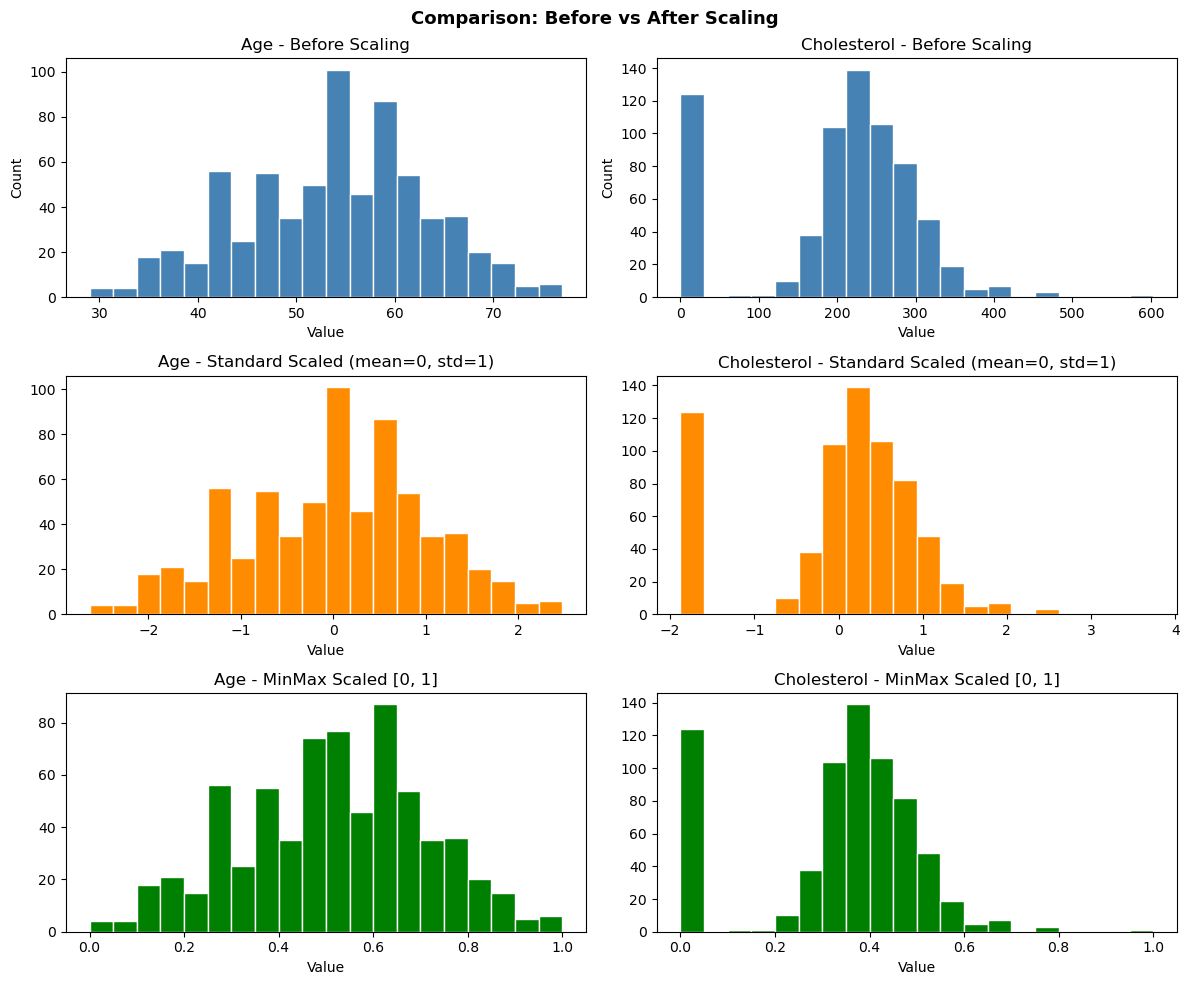

KEY OBSERVATION:
  Shape of distribution does NOT change after scaling!
  Only the range changes.
  StandardScaler: values centered around 0
  MinMaxScaler:   values between 0 and 1


In [76]:
# Now we compare before and after scaling visually

import matplotlib.pyplot as plt
import numpy as np

# Compare Age and Cholesterol before and after scaling
# Note: Heart dataset has no "Fare" column -- using Age and Cholesterol instead
features_to_show = ["Age", "Cholesterol"]
fig, axes = plt.subplots(3, len(features_to_show), figsize=(12, 10))

for j, col in enumerate(features_to_show):
    # Row 1: Before scaling
    axes[0, j].hist(X_train[col], bins=20, color="steelblue", edgecolor="white")
    axes[0, j].set_title(f"{col} - Before Scaling")
    axes[0, j].set_xlabel("Value")
    axes[0, j].set_ylabel("Count")

    # Row 2: After StandardScaler
    col_idx = list(X_train.columns).index(col)
    axes[1, j].hist(X_train_std[:, col_idx], bins=20, color="darkorange", edgecolor="white")
    axes[1, j].set_title(f"{col} - Standard Scaled (mean=0, std=1)")
    axes[1, j].set_xlabel("Value")

    # Row 3: After MinMaxScaler
    axes[2, j].hist(X_train_mm[:, col_idx], bins=20, color="green", edgecolor="white")
    axes[2, j].set_title(f"{col} - MinMax Scaled [0, 1]")
    axes[2, j].set_xlabel("Value")

plt.suptitle("Comparison: Before vs After Scaling", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("KEY OBSERVATION:")
print("  Shape of distribution does NOT change after scaling!")
print("  Only the range changes.")
print("  StandardScaler: values centered around 0")
print("  MinMaxScaler:   values between 0 and 1")

> 📝 **এই code-এ কী হচ্ছে:** Before vs After scaling-এর visual comparison। Row 1: original values — Age ও Fare-এর scale সম্পূর্ণ আলাদা। Row 2: StandardScaler — shape same, কিন্তু range centered at 0। Row 3: MinMaxScaler — shape same, কিন্তু range 0 to 1। Important insight: Scaling shape বদলায় না, শুধু range বদলায়।

In [77]:
# Now we show what happens when you incorrectly fit on test data

from sklearn.preprocessing import StandardScaler
import pandas as pd, numpy as np

# Simulate a case where test has different distribution
np.random.seed(42)
X_tr = pd.DataFrame({"Age": np.random.normal(50, 10, 100),
                      "Fare": np.random.normal(100, 30, 100)})
X_te = pd.DataFrame({"Age": np.random.normal(70, 5, 30),   # different distribution!
                      "Fare": np.random.normal(200, 10, 30)})

# WRONG way: fit on test data (data leakage)
scaler_wrong = StandardScaler()
scaler_wrong.fit(X_te)   # learning test statistics -- WRONG!
X_te_wrong = scaler_wrong.transform(X_te)

# CORRECT way: fit only on train
scaler_correct = StandardScaler()
scaler_correct.fit(X_tr)   # learning train statistics -- CORRECT!
X_te_correct = scaler_correct.transform(X_te)

print("WRONG (fit on test): Test Age mean after transform =",
      X_te_wrong[:, 0].mean().round(4))  # ~0 (test sees its own stats)

print("CORRECT (fit on train): Test Age mean after transform =",
      X_te_correct[:, 0].mean().round(4))  # not 0 (using train stats)

print()
print("Explanation:")
print("  WRONG: test data appears 'perfectly scaled' -- inflated performance")
print("  CORRECT: test data is scaled using training statistics")
print("  In production, the model sees data with TRAINING statistics applied")

WRONG (fit on test): Test Age mean after transform = -0.0
CORRECT (fit on train): Test Age mean after transform = 2.4678

Explanation:
  WRONG: test data appears 'perfectly scaled' -- inflated performance
  CORRECT: test data is scaled using training statistics
  In production, the model sees data with TRAINING statistics applied


> 📝 **এই code-এ কী হচ্ছে:** Data leakage-এর concrete demonstration। Wrong way: test data-তে fit করলে test-এর নিজের mean/std ব্যবহার হয় → test দেখায় perfect scale → inflated performance। Correct way: train-এ fit করলে test production-এর মতো আচরণ পায়। এটা interview-এ সবচেয়ে গুরুত্বপূর্ণ topic।

---
## 7.8 Conclusion — Complete Preprocessing Pipeline

### সম্পূর্ণ Module 07 Summary

| Step | কী করলাম | Method |
|---|---|---|
| Missing Values | Age → median, Embarked → mode, Cabin → drop | `fillna()`, `drop()` |
| Label Encoding | Sex: M=1/F=0, ExerciseAngina: Y=1/N=0 | `LabelEncoder()` |
| OneHot Encoding | ChestPainType, RestingECG, ST_Slope | `pd.get_dummies()` |
| Train/Test Split | 75% train, 25% test | `train_test_split()` |
| StandardScaler | mean=0, std=1, fit only on train | `StandardScaler()` |
| MinMaxScaler | [0,1] range, fit only on train | `MinMaxScaler()` |

### Interview Quick Reference

```
Q: Numeric missing কীভাবে fill করব?
A: Symmetric -> mean, Skewed -> median, Domain-specific -> constant

Q: Categorical missing কীভাবে fill করব?
A: mode() -- most frequent value

Q: Label vs OneHot কখন?
A: Binary/Ordinal -> Label, Nominal (কোনো order নেই) -> OneHot

Q: Dummy variable trap কী?
A: n categories -> n-1 columns যথেষ্ট. drop_first=True দিয়ে fix.

Q: Scaling কি সব model-এ দরকার?
A: KNN, SVM, Linear/Logistic Regression, Neural Net -> YES
   Decision Tree, Random Forest, XGBoost -> NO (scale-invariant)

Q: Data leakage কীভাবে এড়াবে?
A: Scaler.fit() শুধু X_train-এ. X_test-এ শুধু .transform().
   কখনো fit_transform(X_test) নয়!

Q: StandardScaler vs MinMaxScaler?
A: Outlier থাকলে StandardScaler ভালো.
   Fixed [0,1] range দরকার হলে MinMaxScaler.
```


In [78]:
# NOW WE PUT EVERYTHING TOGETHER -- Complete Preprocessing Pipeline
# From raw Heart data to model-ready scaled features

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

print("=" * 55)
print("STEP 1: Load data")
print("=" * 55)
df = pd.read_csv("Heart-Dataset.csv")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

print()
print("=" * 55)
print("STEP 2: Handle missing values")
print("=" * 55)
# Heart dataset has no missing values -- but we show the pattern
for col in df.select_dtypes(include="number").columns:
    n_miss = df[col].isnull().sum()
    if n_miss > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  {col}: filled {n_miss} NaN with median")
for col in df.select_dtypes(include="object").columns:
    n_miss = df[col].isnull().sum()
    if n_miss > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"  {col}: filled {n_miss} NaN with mode")
print("  No missing values to fill in heart.csv!")

print()
print("=" * 55)
print("STEP 3: Label Encoding (binary)")
print("=" * 55)
le = LabelEncoder()
for col in ["Sex", "ExerciseAngina"]:
    df[col] = le.fit_transform(df[col])
    print(f"  {col} encoded: {df[col].unique().tolist()}")

print()
print("=" * 55)
print("STEP 4: OneHot Encoding (nominal)")
print("=" * 55)
cat_cols = ["ChestPainType", "RestingECG", "ST_Slope"]
df = pd.get_dummies(df, columns=cat_cols, dtype=int)
print(f"  Shape after encoding: {df.shape}")

print()
print("=" * 55)
print("STEP 5: Train/Test split")
print("=" * 55)
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f"  X_train: {X_train.shape}, X_test: {X_test.shape}")

print()
print("=" * 55)
print("STEP 6: Standard Scaling (fit ONLY on train!)")
print("=" * 55)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f"  X_train scaled mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"  X_train scaled std  (should be ~1): {X_train_scaled.std():.4f}")

print()
print("=" * 55)
print("PIPELINE COMPLETE! Data is ready for model training.")
print("=" * 55)
print(f"  Final X_train shape: {X_train_scaled.shape}")
print(f"  Final X_test shape:  {X_test_scaled.shape}")

STEP 1: Load data
Shape: (918, 12)
Missing values: 0

STEP 2: Handle missing values
  No missing values to fill in heart.csv!

STEP 3: Label Encoding (binary)
  Sex encoded: [1, 0]
  ExerciseAngina encoded: [0, 1]

STEP 4: OneHot Encoding (nominal)
  Shape after encoding: (918, 19)

STEP 5: Train/Test split
  X_train: (688, 18), X_test: (230, 18)

STEP 6: Standard Scaling (fit ONLY on train!)
  X_train scaled mean (should be ~0): -0.0000
  X_train scaled std  (should be ~1): 1.0000

PIPELINE COMPLETE! Data is ready for model training.
  Final X_train shape: (688, 18)
  Final X_test shape:  (230, 18)


> 📝 **এই code-এ কী হচ্ছে:** Module 07-এর complete preprocessing pipeline একসাথে — শুরু থেকে শেষ। Step 1: Load → Step 2: Missing values → Step 3: Label Encoding → Step 4: OneHot Encoding → Step 5: Split → Step 6: Scale। এই pattern-টাই real ML project-এ প্রতিবার follow করতে হয়। Final output: X_train_scaled ও X_test_scaled — model-এ দেওয়ার জন্য ready।

In [79]:
# BONUS: sklearn Pipeline -- the professional way to preprocess

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split

# Load fresh copy
df_fresh = pd.read_csv("Heart-Dataset.csv")

# Now we manually encode binary columns first (pipeline handles the rest)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_fresh["Sex"]            = le.fit_transform(df_fresh["Sex"])
df_fresh["ExerciseAngina"] = le.fit_transform(df_fresh["ExerciseAngina"])

X = df_fresh.drop(columns=["HeartDisease"])
y = df_fresh["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Now we define which columns get which treatment
numeric_cols     = ["Age","RestingBP","Cholesterol","FastingBS","MaxHR","Oldpeak","Sex","ExerciseAngina"]
categorical_cols = ["ChestPainType","RestingECG","ST_Slope"]

# Now we build the preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler())
    ]), numeric_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_cols),
])

# Here we fit on train, transform both -- automatically handles data leakage!
X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp  = preprocessor.transform(X_test)

print("sklearn Pipeline preprocessing complete!")
print(f"X_train shape: {X_train_pp.shape}")
print(f"X_test shape:  {X_test_pp.shape}")
print()
print("ADVANTAGES of Pipeline:")
print("  1. No data leakage -- fit only on train, guaranteed")
print("  2. Clean code -- all steps in one object")
print("  3. Easy to deploy -- save one object, apply to new data")
print("  4. Works with cross-validation automatically")

# After all sort of preprocessing, now we'll print the DataFrame to see how it looks.
X_train_pp_df = pd.DataFrame(X_train_pp, columns=preprocessor.get_feature_names_out())
X_train_pp_df.head()

sklearn Pipeline preprocessing complete!
X_train shape: (688, 18)
X_test shape:  (230, 18)

ADVANTAGES of Pipeline:
  1. No data leakage -- fit only on train, guaranteed
  2. Clean code -- all steps in one object
  3. Easy to deploy -- save one object, apply to new data
  4. Works with cross-validation automatically


,num__Age,num__RestingBP,num__Cholesterol,num__FastingBS,num__MaxHR,num__Oldpeak,num__Sex,num__ExerciseAngina,cat__ChestPainType_ASY,cat__ChestPainType_ATA,cat__ChestPainType_NAP,cat__ChestPainType_TA,cat__RestingECG_LVH,cat__RestingECG_Normal,cat__RestingECG_ST,cat__ST_Slope_Down,cat__ST_Slope_Flat,cat__ST_Slope_Up
0,0.239292,1.183802,1.307314,1.877849,0.551672,1.900458,0.537019,1.182037,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.239292,1.183802,-1.878000,-0.532524,-1.486343,-0.834739,0.537019,-0.845997,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.558968,0.913811,0.096522,1.877849,0.831400,0.624033,0.537019,-0.845997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-0.293501,-0.166155,-0.210833,-0.532524,-1.446382,-0.834739,0.537019,-0.845997,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.345851,-0.166155,0.990645,-0.532524,-1.526304,0.076994,-1.862131,-0.845997,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


> 📝 **এই code-এ কী হচ্ছে:** Professional-grade sklearn Pipeline দেখানো হয়েছে — job interview ও real project-এ এটাই standard। `ColumnTransformer` দিয়ে numeric ও categorical columns-এ আলাদা preprocessing apply করা হয়েছে। Pipeline automatically ensure করে fit শুধু training data-তে হয় — data leakage impossible। Deployment-এ এই একটি object save করলেই নতুন data-তে apply করা যায়।

---